## MODEL_TRAIN

In [14]:
# 1. IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb                             # Gradient boosting model
from sklearn.metrics import mean_absolute_error 
from sklearn.model_selection import KFold          # Cross-validation
from sklearn.preprocessing import StandardScaler   # Evaluation metric

In [3]:
# 2. LOAD DATA
df = pd.read_csv("train.csv", nrows=5000000)

In [4]:
# 3. FEATURE ENGINEERING
def create_features(segment):
    x = segment['acoustic_data'].values.astype(np.float32)
    features = {}

    features['mean'] = x.mean()
    features['std'] = x.std()
    features['max'] = x.max()
    features['min'] = x.min()
    features['range'] = x.max() - x.min()

    features['abs_mean'] = np.abs(x).mean()
    features['energy'] = np.sum(x**2) / len(x)

    features['q05'] = np.percentile(x, 5)
    features['q95'] = np.percentile(x, 95)

    features['trend'] = np.polyfit(np.arange(len(x)), x, 1)[0]

    features['zero_cross'] = np.mean(np.diff(np.sign(x)) != 0)
    features['ptp'] = np.ptp(x)

    roll = pd.Series(x).rolling(1000)
    features['roll_std'] = roll.std().mean()

    s = pd.Series(x)
    features['skew'] = s.skew()
    features['kurtosis'] = s.kurtosis()

    # chunk features
    chunks = 5   # Number of segments to divide the signal into

    size = len(x) // chunks  # Size of each chunk
    means = []               # Store mean of each chunk

    for i in range(chunks):
        part = x[i*size:(i+1)*size]    # Extract a portion of the signal
        m = part.mean()                # Calculate mean of this chunk
        features[f'mean_{i}'] = m      # Store chunk mean as a feature
        means.append(m)                # Store chunk mean as a feature


    features['mean_diff'] = means[-1] - means[0]    # Difference between last and first chunk mean

    

   # Frequency Domain Features (FFT) :-
        #  -Converts signal from time domain - frequency domain
        # - Helps detect hidden patterns like periodicity and noise
    
    fft = np.fft.rfft(x)       # Apply Fast Fourier Transform (real-valued)

    fft_mag = np.abs(fft)      # Get magnitude of frequency components

     # mean,average,variation(std),max :- frequencies of magnitude
    features['fft_mean'] = fft_mag.mean()  
    features['fft_std'] = fft_mag.std()
    features['fft_max'] = fft_mag.max()

    return features



In [5]:
def create_segments(df, segment_size=150000, step_size=10000):     # Function to generate feature-target pairs from raw data
      # X will store feature dictionaries
     # y will store corresponding target values
    X, y = [], []

    for start in range(0, len(df) - segment_size, step_size):     # Loop over dataset with a sliding window
        segment = df.iloc[start:start + segment_size]              # Extract a chunk of data

        X.append(create_features(segment))
        y.append(segment['time_to_failure'].values[-1])

    return pd.DataFrame(X), np.array(y)                             # Convert features into DataFrame and target into array

In [6]:
# 4. CREATE DATA
X, y = create_segments(df)
print("X shape:", X.shape)

X shape: (485, 24)


In [15]:
# 5. K-FOLD TRAINING

kf = KFold(n_splits=5, shuffle=True, random_state=42)   # Create 5-fold cross-validation
                                                        # shuffle=True ensures randomness (better generalization)
                                                        # random_state=42 makes results reproducible



params = {
    "objective": "regression",           # Model is solving a regression problem (continuous output)
    "metric": "mae",                     # Evaluation metric = Mean Absolute Error

    "learning_rate": 0.005,              # Controls how fast model learns

    "num_leaves": 64,                    # Maximum leaves per tree

    "min_data_in_leaf": 50,              # Minimum samples per leaf
    
    "feature_fraction": 0.8,             # Use 80% of features randomly
    
    "bagging_fraction": 0.8,             #Use 80% of data randomly
    
    "bagging_freq": 5,                   # Perform bagging every 5 iterations
    
    "lambda_l1": 0.5,                    #L1 regularization ,Helps reduce overfitting by penalizing large weights
    
    "lambda_l2": 0.5,                    # L2 regularization, Stabilizes model and improves generalization
    
    "verbosity": -1                      # Suppress training logs. Keeps output clean

}
# oof (out-of-fold predictions)
oof_preds = np.zeros(len(X))   # Initialize array for out-of-fold predictions
models = []
all_evals = []                 # Store evaluation results from each fold


In [8]:

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n===== FOLD {fold+1} =====")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]        # Split dataset into training and validation
    y_train, y_val = y[train_idx], y[val_idx]                   # Model learns on training data and is evaluated on unseen validation data

    
    scaler = StandardScaler()                                   # Scaling normalizes feature values improves model performance
    X_train = scaler.fit_transform(X_train)                      # Fit scaler on training data and transform it
    X_val = scaler.transform(X_val)                               # Apply same scaling to validation data 

    evals_result = {}                                             # Dictionary to store evaluation results during training


    # Training dataset
    model = lgb.train(
        params,
        lgb.Dataset(X_train, label=y_train),
        valid_sets=[
            lgb.Dataset(X_train, label=y_train),        
            lgb.Dataset(X_val, label=y_val)              # Provide both train and validation sets, Allows monitoring of overfittingc

        ],
        valid_names=['train', 'valid'],              # Names for datasets in logs
        num_boost_round=4000,                        # Maximum number of boosting iterations, More rounds allow better learning

        callbacks=[           
            lgb.early_stopping(200),                  # Stops training if no improvement in 200 rounds
            lgb.record_evaluation(evals_result)       # Records evaluation metrics 
        ]
    )

    preds = model.predict(X_val)                   # Generate predictions on validation data,  Used to evaluate model performance
    preds = np.clip(preds, 0, 16)                 # Restrict predictions within range [0, 16] Prevents unrealistic predictions outside expected bounds


    oof_preds[val_idx] = preds                           # Store out-of-fold predictions , Used for overall model evaluation


    models.append(model)                              # Save trained model

    all_evals.append(evals_result)                    # Save evaluation history


    print("Fold MAE:", mean_absolute_error(y_val, preds))       # Tracks model performance across folds


===== FOLD 1 =====
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[4000]	train's l1: 0.0692148	valid's l1: 0.0951052
Fold MAE: 0.09510523997087288

===== FOLD 2 =====
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[4000]	train's l1: 0.0678053	valid's l1: 0.113693
Fold MAE: 0.1136932110857217

===== FOLD 3 =====
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[4000]	train's l1: 0.0697312	valid's l1: 0.0929086
Fold MAE: 0.09290854899775362

===== FOLD 4 =====
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[4000]	train's l1: 0.0689769	valid's l1: 0.105697
Fold MAE: 0.10569705598185238

===== FOLD 5 =====
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[4000]	train's l1: 0.0673762	

In [9]:

# 6. FINAL SCORE

final_mae = mean_absolute_error(y, oof_preds)
print("\nFINAL CV MAE:", final_mae)


FINAL CV MAE: 0.10603608480686683


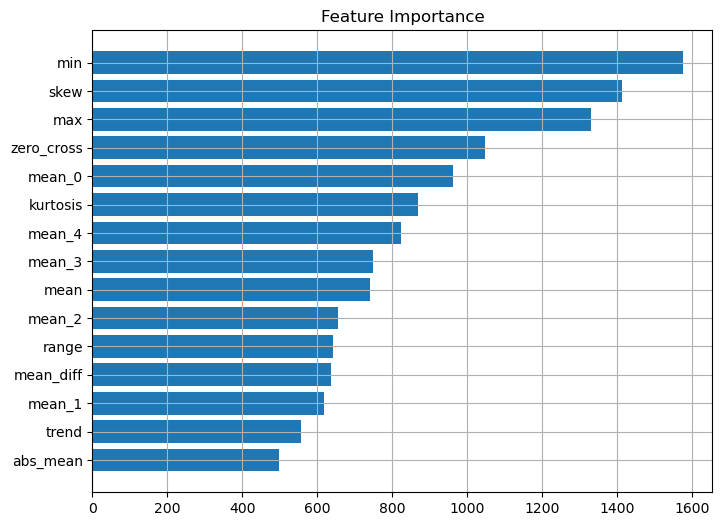

In [10]:

# 7. FEATURE IMPORTANCE

importances = np.mean([m.feature_importance() for m in models], axis=0)

imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(imp_df["feature"][:15][::-1], imp_df["importance"][:15][::-1])
plt.title("Feature Importance")
plt.grid()
plt.show()

#####
- Helps understand which features contribute most to predictions
- Useful for feature selection and model improvement
- Improves interpretability of the model

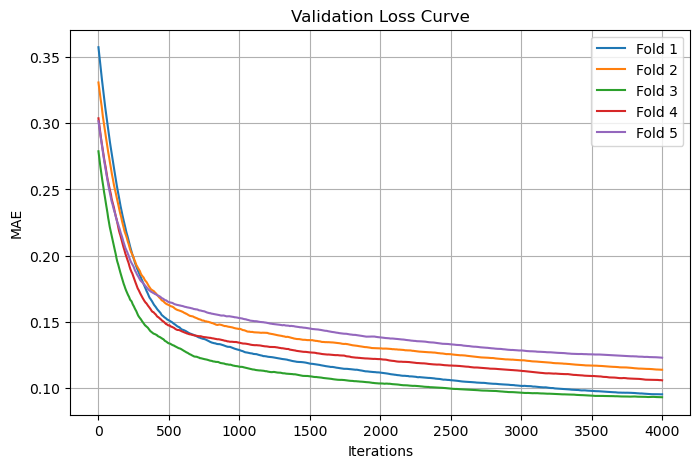

In [11]:

# 8. LOSS CURVE

plt.figure(figsize=(8,5))

for i, ev in enumerate(all_evals):
    plt.plot(ev['valid']['l1'], label=f"Fold {i+1}")

plt.title("Validation Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("MAE")
plt.legend()
plt.grid()
plt.show()

####
 - Learning behavior graph :-
 - If MAE keeps decreasing model is learning
 - If it stops early learning is limited
 - To see how your model is learning during training

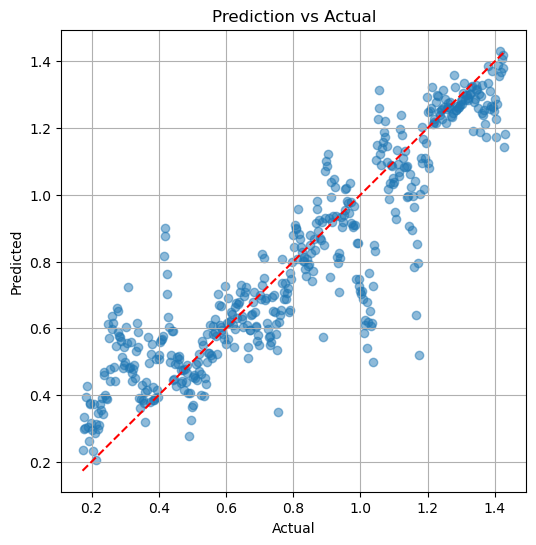

In [12]:
# 9. PREDICTION VS ACTUAL

plt.figure(figsize=(6,6))
plt.scatter(y, oof_preds, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual")
plt.grid()
plt.show()

#### Prediction vs Actual
- How close the model’s predictions are to the real values
- Helps visually evaluate model accuracy
- Identifies errors, bias, and prediction spread

In [13]:
# 10. SAVE MODEL

import pickle                                 # Import pickle library
with open("final_model.pkl", "wb") as f:    
    pickle.dump(models, f)                     # Save trained models into file

print("Model Saved")

Model Saved
